<a href="https://colab.research.google.com/github/ArveySuarez/ModelosAnaliticosUnicafam202607/blob/main/Clusters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [10]:
import pandas as pd
df = pd.read_excel("/content/crime_data.xlsx")

In [12]:
if "Unnamed: 0" in df.columns:
    df = df.rename(columns={"Unnamed: 0": "State"})
    print("--- PRIMERAS FILAS DEL DATASET ---")
    print(df.head())
    print("\n--- INFORMACIÓN DEL DATASET ---")
    print(df.info())
    print("\n--- RESUMEN ESTADÍSTICO ---")
    print(df.describe())

--- PRIMERAS FILAS DEL DATASET ---
        State  Murder  Assault  UrbanPop  Rape
0     Alabama    13.2      236        58  21.2
1      Alaska    10.0      263        48  44.5
2     Arizona     8.1      294        80  31.0
3    Arkansas     8.8      190        50  19.5
4  California     9.0      276        91  40.6

--- INFORMACIÓN DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB
None

--- RESUMEN ESTADÍSTICO ---
         Murder     Assault   UrbanPop       Rape
count  50.00000   50.000000  50.000000  50.000000
mean    7.78800  170.760000  65.540000  21.232000
std     4.35551   83.337661  

In [13]:
from sklearn.preprocessing import StandardScaler
features = ["Murder", "Assault", "UrbanPop", "Rape"]
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("--- DATOS ESTANDARIZADOS (PRIMERAS 5 FILAS) ---")
print(X_scaled_df.head())

--- DATOS ESTANDARIZADOS (PRIMERAS 5 FILAS) ---
     Murder   Assault  UrbanPop      Rape
0  1.255179  0.790787 -0.526195 -0.003451
1  0.513019  1.118060 -1.224067  2.509424
2  0.072361  1.493817  1.009122  1.053466
3  0.234708  0.233212 -1.084492 -0.186794
4  0.281093  1.275635  1.776781  2.088814


In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("--- CANTIDAD DE ESTADOS POR CLÚSTER ---")
print(df["Cluster"].value_counts())
print("\n--- MUESTRA DE ESTADOS CON SU CLÚSTER ASIGNADO ---")
print(df[["State", "Murder", "Assault", "Rape", "Cluster"]].head(10))

--- CANTIDAD DE ESTADOS POR CLÚSTER ---
Cluster
1    20
0    16
2    14
Name: count, dtype: int64

--- MUESTRA DE ESTADOS CON SU CLÚSTER ASIGNADO ---
         State  Murder  Assault  Rape  Cluster
0      Alabama    13.2      236  21.2        1
1       Alaska    10.0      263  44.5        1
2      Arizona     8.1      294  31.0        1
3     Arkansas     8.8      190  19.5        2
4   California     9.0      276  40.6        1
5     Colorado     7.9      204  38.7        1
6  Connecticut     3.3      110  11.1        0
7     Delaware     5.9      238  15.8        0
8      Florida    15.4      335  31.9        1
9      Georgia    17.4      211  25.8        1


In [15]:
resumen_clusters = (df.groupby("Cluster")[["Murder", "Assault", "UrbanPop", "Rape"]].mean().round(2))

print("--- PROMEDIO DE DELITOS POR CLÚSTER ---")
print(resumen_clusters)

--- PROMEDIO DE DELITOS POR CLÚSTER ---
         Murder  Assault  UrbanPop   Rape
Cluster                                  
0          5.66   138.88     73.88  18.78
1         12.16   255.25     68.40  29.16
2          3.97    86.50     51.93  12.70


In [16]:
mapeo_niveles = {1: "Alta Complejidad",0: "Media Complejidad",2: "Baja Complejidad",}
df["Nivel_Complejidad"] = df["Cluster"].map(mapeo_niveles)
print("--- CONTEO DE ESTADOS POR NIVEL DE COMPLEJIDAD ---")
print(df["Nivel_Complejidad"].value_counts())

--- CONTEO DE ESTADOS POR NIVEL DE COMPLEJIDAD ---
Nivel_Complejidad
Alta Complejidad     20
Media Complejidad    16
Baja Complejidad     14
Name: count, dtype: int64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
colores = {
    "Alta Complejidad": "red",
    "Media Complejidad": "orange",
    "Baja Complejidad": "green",}

<Figure size 1200x700 with 0 Axes>

<Axes: xlabel='Assault', ylabel='Murder'>

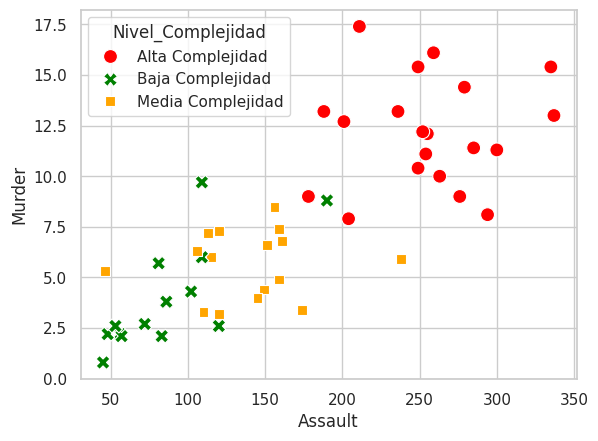

In [18]:
sns.scatterplot(data=df,x="Assault",y="Murder",hue="Nivel_Complejidad",palette=colores,s=100,style="Nivel_Complejidad",
)

Conclusiones

Clasificación: Se dividieron los 50 estados en 3 niveles: 20 de Alta Complejidad, 16 de Media Complejidad y 14 de Baja Complejidad.

Estados Críticos: Los 20 estados de Alta Complejidad (como California, Florida, New York, Texas) registran la mayor tasa de violencia y requieren atención prioritaria.

Distribución de Policías Capacitados (300): Se asignan 240 a los estados de Alta Complejidad y 60 a los de Media Complejidad.

Distribución de Policías de a Pie (500): Se concentran principalmente en la Media Complejidad (240) para combatir la delincuencia común, asignando 160 a Alta y 100 a Baja.

Protección de Cadetes (150): Se despliegan 112 en Baja Complejidad y 38 en Media Complejidad; 0 en Alta Complejidad para no exponer personal sin experiencia a un alto riesgo.